Sequential Flow:

START --> Calculate BMI (Boss Mass Index) (Weight in KG / [Height in Meters**2]) --> Specify Category --> END

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
class BMIState(TypedDict):
    weight_kg : float
    height_m : float
    bmi: float
    category: str

In [3]:
def calculate_bmi(state:BMIState)->BMIState:
    weight_kg = state['weight_kg']
    height_m = state['height_m']

    bmi = weight_kg/(height_m**2)

    state['bmi'] = round(bmi,2)

    return state

In [4]:
def specify_bmi_category(state:BMIState)->BMIState:
    bmi = state['bmi']

    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"
    
    return state


In [5]:
# Define Graph
graph = StateGraph(BMIState)

In [6]:
# Add nodes in Graph
graph.add_node('calculate_bmi',calculate_bmi)
graph.add_node('specify_bmi_category',specify_bmi_category)

In [7]:
# Add edges in Graph
graph.add_edge(START,'calculate_bmi')
graph.add_edge('calculate_bmi','specify_bmi_category')
graph.add_edge('specify_bmi_category',END)

In [8]:
workflow= graph.compile()

In [11]:
input = {'weight_kg':52,'height_m':1.73}

output = workflow.invoke(input)

print(output)

{'weight_kg': 52, 'height_m': 1.73, 'bmi': 17.37, 'category': 'Underweight'}


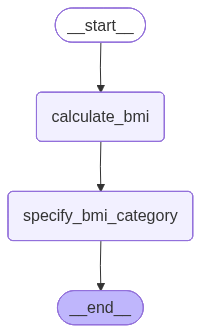

In [12]:
# Display the Graph

from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())